In [56]:
from collections.abc import Collection

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.random import randn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier, plot_importance
from collections import Counter

In [57]:
%store -r export_df_1y
df_1y = export_df_1y

%store -r export_df_5y
df_5y = export_df_5y

%store -r export_df_10y
df_10y = export_df_10y

In [104]:
df = df_1y

buy_sell = df[df['target'] != 0]
hold = df[df['target'] == 0]
hold = hold.sample(n=min(len(hold), len(buy_sell)), random_state=42)

df = pd.concat([buy_sell, hold])

X, y = df.drop(columns=['target']), df['target'].apply(lambda x: x + 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
Counter(train_y)

Counter({1: 9739, 2: 5011, 0: 4741})

In [106]:
classes = np.unique(train_y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_y)

class_weights_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weights_dict[y] for y in train_y])

print(class_weights_dict)
print(sample_weights)

{np.int64(0): np.float64(1.370385994515925), np.int64(1): np.float64(0.6671116131019612), np.int64(2): np.float64(1.2965475952903611)}
[0.66711161 1.37038599 0.66711161 ... 1.2965476  0.66711161 0.66711161]


In [112]:
xgb = XGBClassifier(
    n_estimators=200,
    objective='multi:softprob',
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    reg_lambda=2.0,
    random_state=42
)
xgb.fit(train_X, train_y, sample_weight=sample_weights)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [114]:
pred_y = xgb.predict(test_X)

In [115]:
print(classification_report(y_true=test_y, y_pred=pred_y))
print(accuracy_score(y_true=test_y, y_pred=pred_y))
confusion_matrix(y_true=test_y, y_pred=pred_y)

              precision    recall  f1-score   support

           0       0.39      0.43      0.41      1176
           1       0.68      0.63      0.65      2443
           2       0.45      0.47      0.46      1254

    accuracy                           0.54      4873
   macro avg       0.51      0.51      0.51      4873
weighted avg       0.55      0.54      0.54      4873

0.5401190231890006


array([[ 506,  358,  312],
       [ 485, 1533,  425],
       [ 313,  348,  593]])

In [127]:
pd.Series(pred_y).value_counts()

1    2239
2    1330
0    1304
Name: count, dtype: int64

In [128]:
pd.Series(test_y).value_counts()

target
1    2443
2    1254
0    1176
Name: count, dtype: int64

In [113]:
importances_df = pd.DataFrame({
    "feature": train_X.columns,
    "importance": xgb.feature_importances_
})
importances_df['importance'] = importances_df['importance'].apply(lambda x: x * 100)
importances_df

,feature,importance
0,open,1.751444
1,high,2.256047
2,low,2.161505
3,close,2.247118
4,volume,3.180540
5,rsi_6,1.920368
6,rsi_12,1.943796
7,macd,2.049595
8,macd_signal,2.023168
9,macd_hist,2.112122


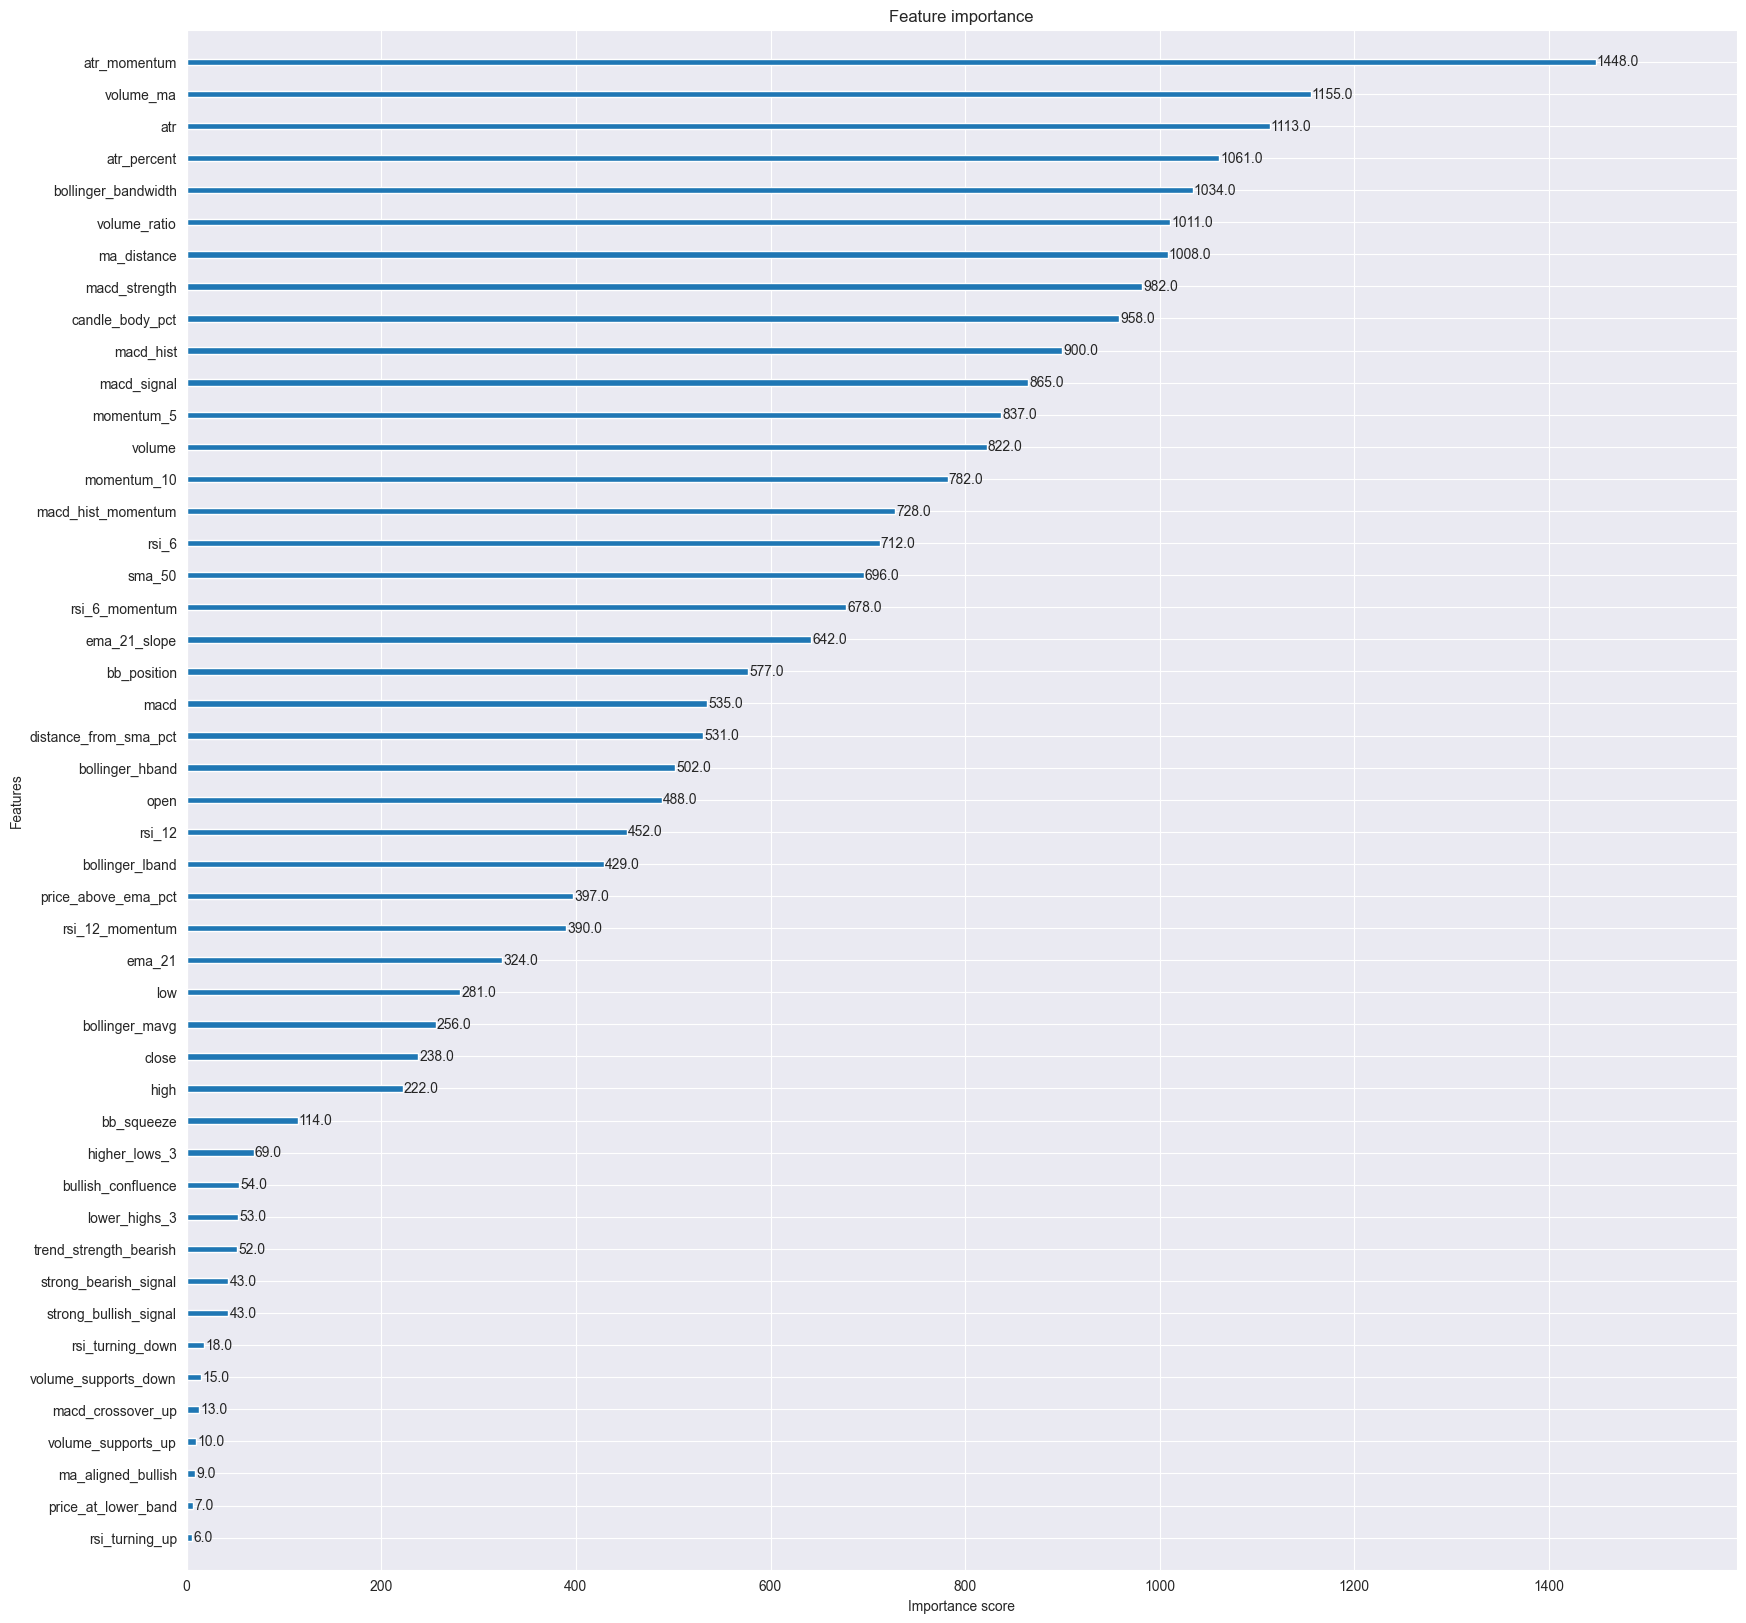

In [70]:
fig, ax = plt.subplots(figsize=(20, 20))
plot_importance(xgb, ax=ax)
plt.show()

In [111]:
features_to_drop = importances_df[importances_df['importance'] < 1.0]['feature']
train_X.drop(columns=features_to_drop, inplace=True)
test_X.drop(columns=features_to_drop, inplace=True)

In [94]:
xgb.fit(train_X, train_y)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
